In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

df = pd.read_csv("/content/cleaned_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (15000, 16)


,Date,Product_ID,Category,Price,Discount,On_Promotion,Weekend,Month,DayOfWeek,Current_Stock,Sales_Quantity,Revenue,Supplier_Lead_Time,Stockout_Risk,Yesterday_Sales,Avg_Sales_7Days
0,2025-01-01,SKU_0001,Beauty,57.54,0,0,0,1,2,122,101,5811.54,3,0,0,101.00
1,2025-01-02,SKU_0001,Beauty,57.54,15,1,0,1,3,163,149,7287.44,3,1,101,125.00
2,2025-01-03,SKU_0001,Beauty,57.54,0,0,0,1,4,94,102,5869.08,3,1,149,117.33
3,2025-01-04,SKU_0001,Beauty,57.54,0,0,1,1,5,178,139,7998.06,3,0,102,122.75
4,2025-01-05,SKU_0001,Beauty,57.54,0,0,1,1,6,149,137,7882.98,3,1,139,125.60


In [4]:
# Overall sales and revenue summary

total_units = df["Sales_Quantity"].sum()
total_revenue = df["Revenue"].sum()
average_daily_sales = df["Sales_Quantity"].mean()

print("===== OVERALL SALES SUMMARY =====")
print("Total Units Sold:", total_units)
print("Total Revenue:", round(total_revenue, 2))
print("Average Sales per Record:", round(average_daily_sales, 2))

===== OVERALL SALES SUMMARY =====
Total Units Sold: 1637929
Total Revenue: 116413261.32
Average Sales per Record: 109.2


In [5]:
# Total sales by category

category_sales = (
    df.groupby("Category")["Sales_Quantity"]
      .sum()
      .sort_values(ascending=False)
)

print("===== SALES BY CATEGORY =====")
print(category_sales)

===== SALES BY CATEGORY =====
Category
Home & Kitchen    393852
Beauty            380512
Apparel           327625
Sports            293275
Electronics       242665
Name: Sales_Quantity, dtype: int64


In [7]:
import matplotlib.pyplot as plt

In [ ]:
# Visualize sales by category

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales Quantity by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Daily total sales

daily_sales = (
    df.groupby("Date")["Sales_Quantity"]
      .sum()
)

print("===== DAILY SALES =====")
print(daily_sales.head())

===== DAILY SALES =====
Date
2025-01-01     9939
2025-01-02    10059
2025-01-03     9857
2025-01-04    13319
2025-01-05    13370
Name: Sales_Quantity, dtype: int64


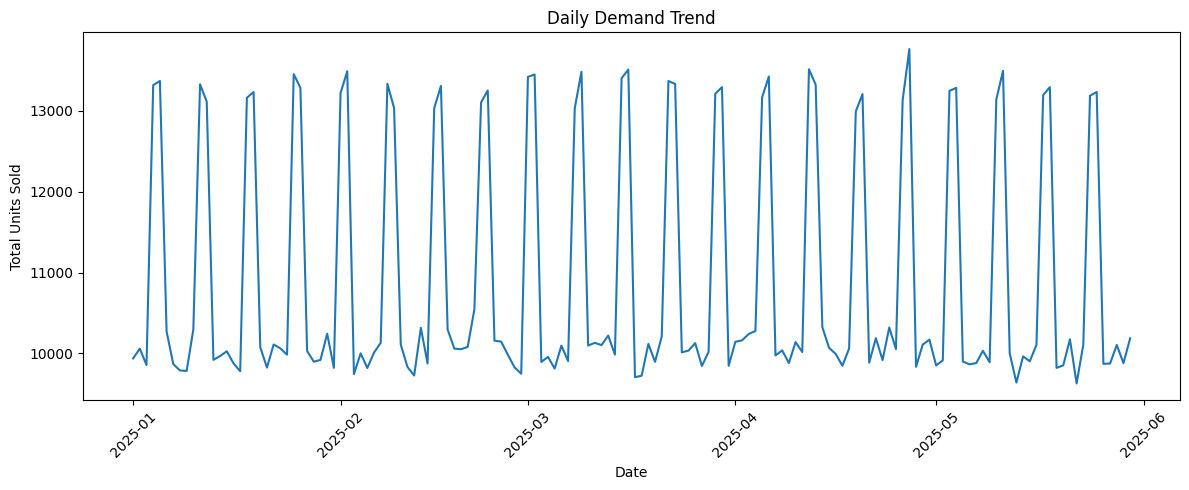

In [9]:
# Plot daily demand trend

plt.figure(figsize=(12, 5))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Compare weekday and weekend demand

weekend_sales = (
    df.groupby("Weekend")["Sales_Quantity"]
      .agg(["sum", "mean", "count"])
)

print("===== WEEKDAY vs WEEKEND SALES =====")
print(weekend_sales)

===== WEEKDAY vs WEEKEND SALES =====
             sum        mean  count
Weekend                            
0        1079750   99.976852  10800
1         558179  132.899762   4200


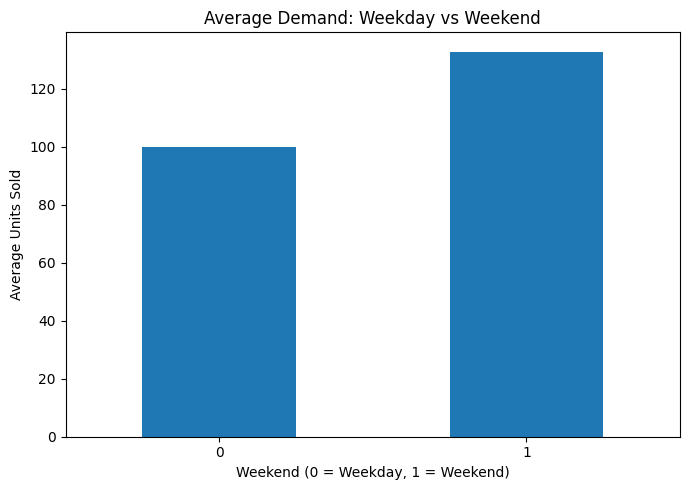

In [11]:
# Average sales on weekdays vs weekends

plt.figure(figsize=(7, 5))

weekend_sales["mean"].plot(kind="bar")

plt.title("Average Demand: Weekday vs Weekend")
plt.xlabel("Weekend (0 = Weekday, 1 = Weekend)")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Top 10 products by total sales

top_products = (
    df.groupby("Product_ID")["Sales_Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("===== TOP 10 PRODUCTS =====")
print(top_products)

===== TOP 10 PRODUCTS =====
Product_ID
SKU_0023    20421
SKU_0095    20381
SKU_0017    20373
SKU_0039    20344
SKU_0052    20007
SKU_0064    19993
SKU_0033    19990
SKU_0047    19863
SKU_0003    19794
SKU_0056    19728
Name: Sales_Quantity, dtype: int64


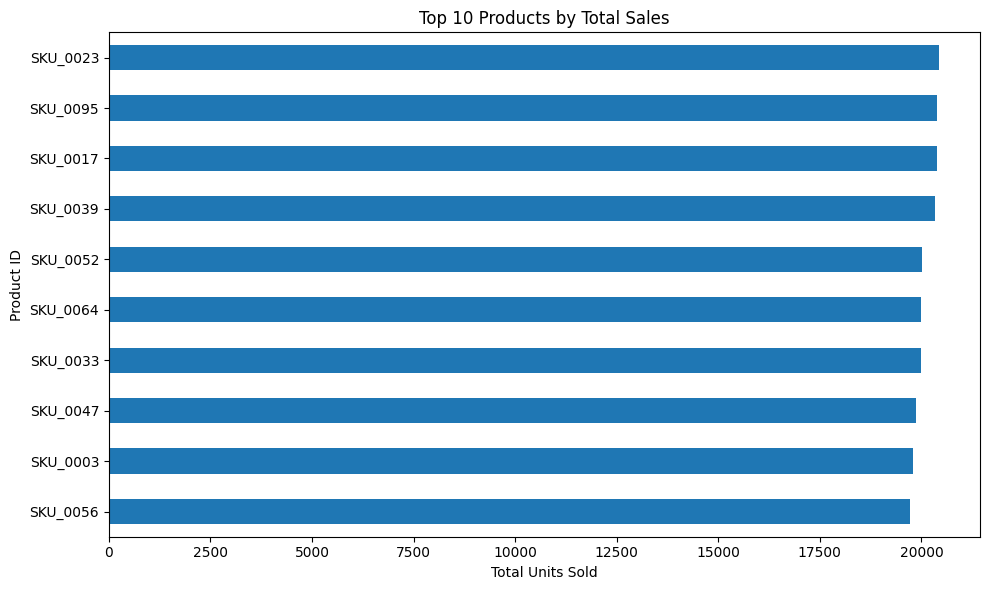

In [13]:
# Plot top 10 products

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Units Sold")
plt.ylabel("Product ID")

plt.tight_layout()
plt.show()

In [14]:
# Bottom 10 products by total sales

bottom_products = (
    df.groupby("Product_ID")["Sales_Quantity"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

print("===== BOTTOM 10 PRODUCTS =====")
print(bottom_products)

===== BOTTOM 10 PRODUCTS =====
Product_ID
SKU_0096     5281
SKU_0059     5368
SKU_0060     5477
SKU_0051     7771
SKU_0028     8212
SKU_0065     8802
SKU_0037     9051
SKU_0084     9631
SKU_0081     9814
SKU_0093    10647
Name: Sales_Quantity, dtype: int64


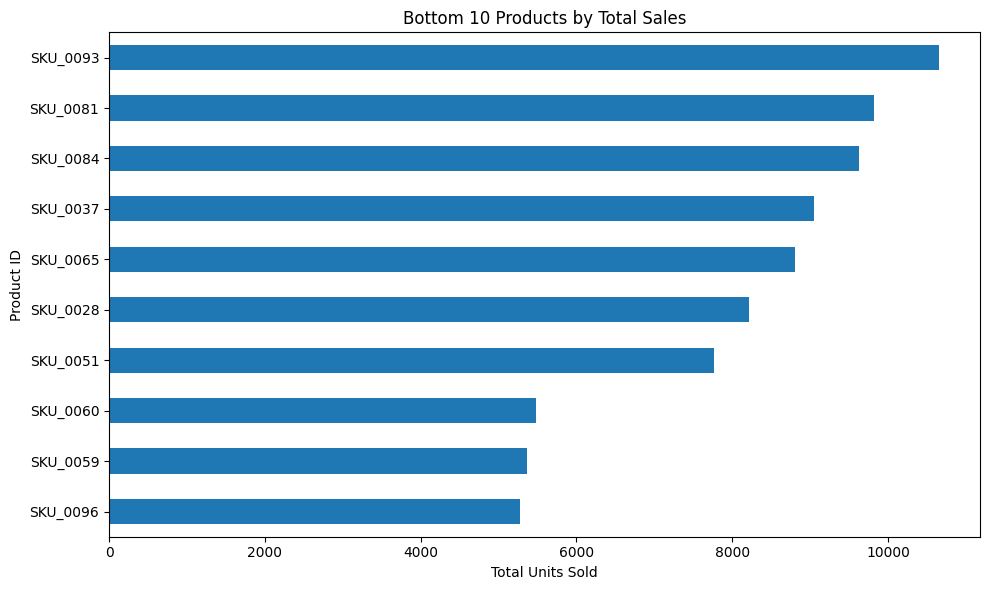

In [15]:
# Plot bottom 10 products

plt.figure(figsize=(10, 6))

bottom_products.plot(kind="barh")

plt.title("Bottom 10 Products by Total Sales")
plt.xlabel("Total Units Sold")
plt.ylabel("Product ID")

plt.tight_layout()
plt.show()

In [16]:
# Product-level inventory and demand analysis

product_analysis = (
    df.groupby("Product_ID")
      .agg(
          Total_Sales=("Sales_Quantity", "sum"),
          Avg_Daily_Sales=("Sales_Quantity", "mean"),
          Avg_Stock=("Current_Stock", "mean")
      )
)

# Estimate how many days the average stock can cover
product_analysis["Stock_Coverage_Days"] = (
    product_analysis["Avg_Stock"] /
    product_analysis["Avg_Daily_Sales"]
)

# Sort by sales
product_analysis = product_analysis.sort_values("Total_Sales")

print("===== PRODUCT INVENTORY ANALYSIS =====")
print(product_analysis.head(10))

===== PRODUCT INVENTORY ANALYSIS =====
            Total_Sales  Avg_Daily_Sales  Avg_Stock  Stock_Coverage_Days
Product_ID                                                              
SKU_0096           5281        35.206667  47.960000             1.362242
SKU_0059           5368        35.786667  47.820000             1.336252
SKU_0060           5477        36.513333  50.766667             1.390360
SKU_0051           7771        51.806667  67.793333             1.308583
SKU_0028           8212        54.746667  69.646667             1.272163
SKU_0065           8802        58.680000  72.013333             1.227221
SKU_0037           9051        60.340000  76.306667             1.264612
SKU_0084           9631        64.206667  79.486667             1.237982
SKU_0081           9814        65.426667  81.646667             1.247911
SKU_0093          10647        70.980000  87.080000             1.226824


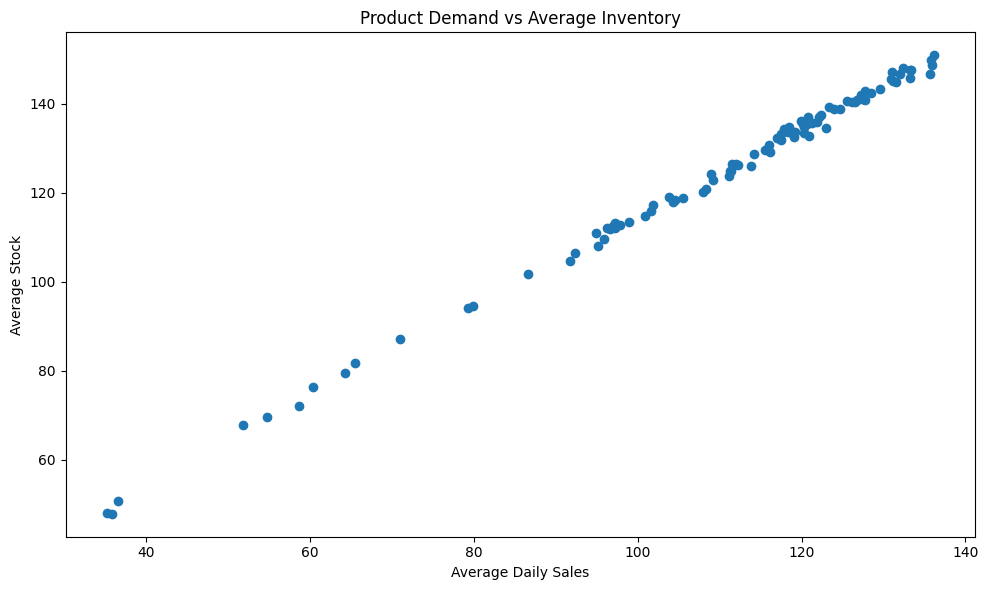

In [17]:
# Visualize demand vs inventory

plt.figure(figsize=(10, 6))

plt.scatter(
    product_analysis["Avg_Daily_Sales"],
    product_analysis["Avg_Stock"]
)

plt.title("Product Demand vs Average Inventory")
plt.xlabel("Average Daily Sales")
plt.ylabel("Average Stock")

plt.tight_layout()
plt.show()

In [18]:
# Compare demand during promotions vs non-promotions

promotion_analysis = (
    df.groupby("On_Promotion")["Sales_Quantity"]
      .agg(["sum", "mean", "count"])
)

print("===== PROMOTION vs NON-PROMOTION DEMAND =====")
print(promotion_analysis)

===== PROMOTION vs NON-PROMOTION DEMAND =====
                  sum        mean  count
On_Promotion                            
0             1310178  102.445696  12789
1              327751  148.236545   2211


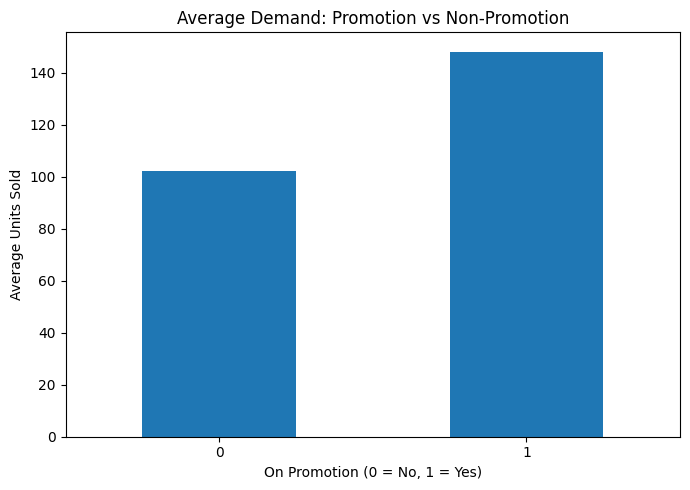

In [19]:
# Visualize promotion impact on demand

plt.figure(figsize=(7, 5))

promotion_analysis["mean"].plot(kind="bar")

plt.title("Average Demand: Promotion vs Non-Promotion")
plt.xlabel("On Promotion (0 = No, 1 = Yes)")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [20]:
# Demand by discount level

discount_analysis = (
    df.groupby("Discount")["Sales_Quantity"]
      .agg(["mean", "sum", "count"])
)

print("===== DEMAND BY DISCOUNT =====")
print(discount_analysis)

===== DEMAND BY DISCOUNT =====
                mean      sum  count
Discount                            
0         102.445696  1310178  12789
5         146.569554    55843    381
10        145.434043    68354    470
15        150.437500    67396    448
20        149.822222    67420    450
25        148.783550    68738    462


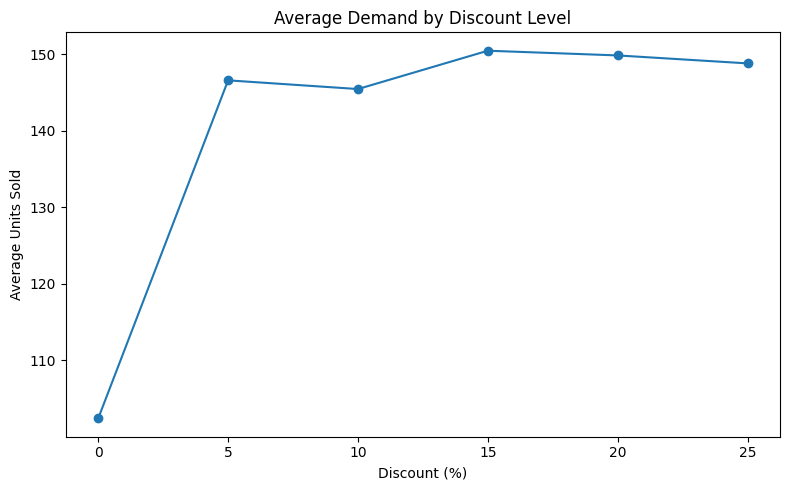

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    discount_analysis.index,
    discount_analysis["mean"],
    marker="o"
)

plt.title("Average Demand by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

In [22]:
# Revenue by category

category_revenue = (
    df.groupby("Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print("===== REVENUE BY CATEGORY =====")
print(category_revenue)

===== REVENUE BY CATEGORY =====
Category
Electronics       36364930.46
Home & Kitchen    31581023.33
Sports            19603330.63
Apparel           16017110.78
Beauty            12846866.12
Name: Revenue, dtype: float64


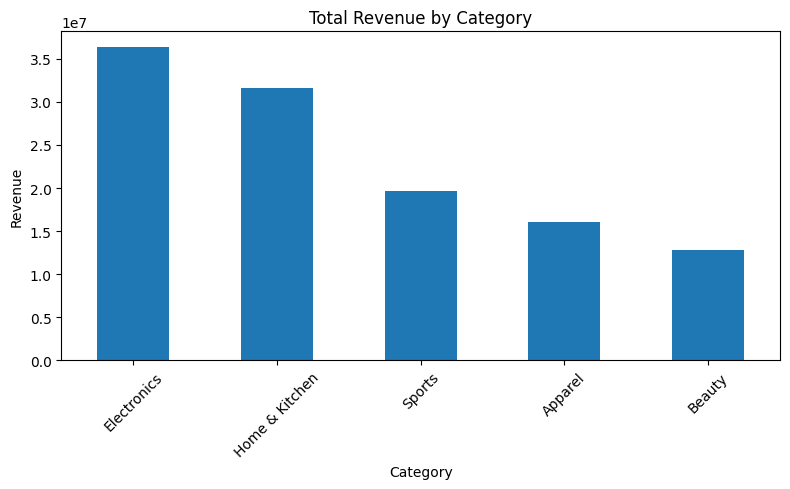

In [23]:
# Visualize revenue by category

plt.figure(figsize=(8, 5))

category_revenue.plot(kind="bar")

plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Stockout risk analysis

risk_analysis = (
    df.groupby("Stockout_Risk")["Sales_Quantity"]
      .agg(["sum", "mean", "count"])
)

print("===== STOCKOUT RISK ANALYSIS =====")
print(risk_analysis)

===== STOCKOUT RISK ANALYSIS =====
                   sum        mean  count
Stockout_Risk                            
0               516788   97.543979   5298
1              1121141  115.557720   9702


In [25]:
# Number of records by stockout risk

risk_counts = df["Stockout_Risk"].value_counts().sort_index()

print("===== STOCKOUT RISK COUNTS =====")
print(risk_counts)

===== STOCKOUT RISK COUNTS =====
Stockout_Risk
0    5298
1    9702
Name: count, dtype: int64


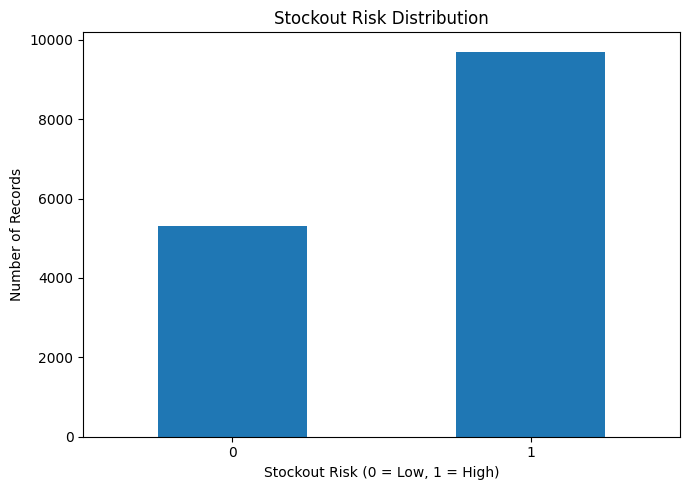

In [26]:
# Visualize stockout risk

plt.figure(figsize=(7, 5))

risk_counts.plot(kind="bar")

plt.title("Stockout Risk Distribution")
plt.xlabel("Stockout Risk (0 = Low, 1 = High)")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [27]:
# Stockout risk by category

category_risk = (
    df.groupby("Category")["Stockout_Risk"]
      .agg(["sum", "count", "mean"])
      .sort_values("mean", ascending=False)
)

category_risk["Risk_Percentage"] = category_risk["mean"] * 100

print("===== STOCKOUT RISK BY CATEGORY =====")
print(category_risk)

===== STOCKOUT RISK BY CATEGORY =====
                 sum  count      mean  Risk_Percentage
Category                                              
Beauty          2162   3000  0.720667        72.066667
Apparel         1898   2700  0.702963        70.296296
Sports          1712   2550  0.671373        67.137255
Home & Kitchen  2309   3600  0.641389        64.138889
Electronics     1621   3150  0.514603        51.460317


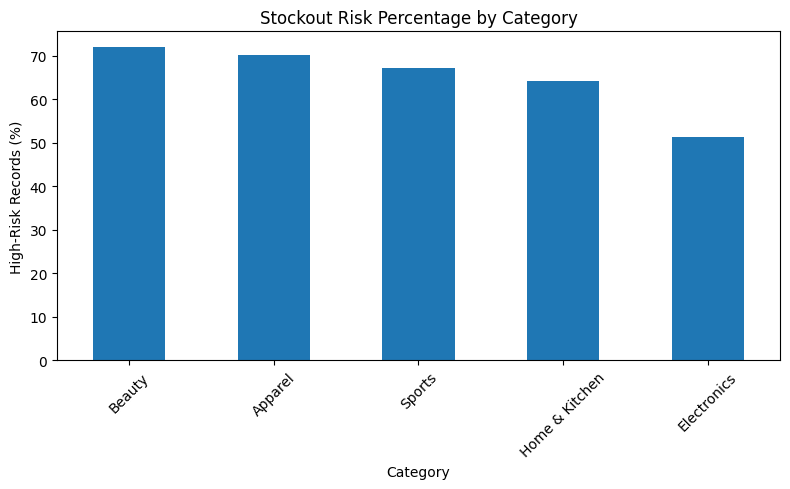

In [28]:
# Visualize stockout risk percentage by category

plt.figure(figsize=(8, 5))

category_risk["Risk_Percentage"].plot(kind="bar")

plt.title("Stockout Risk Percentage by Category")
plt.xlabel("Category")
plt.ylabel("High-Risk Records (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()